# 4. Validación Cruzada: La Crisis del Tequila (México 1994)

---

## Recapitulación del Proyecto

Hasta ahora hemos:

1. **Analizado** la crisis del Miércoles Negro (UK 1992)
2. **Desarrollado** un algoritmo basado en Danger Theory
3. **Validado** su robustez con datos sintéticos

Ahora viene la prueba definitiva: **¿Funciona el modelo en una crisis completamente diferente?**

---

## Objetivo de este Notebook

Aplicar el agente entrenado en UK 1992 a la **Crisis del Tequila** de México (1994) para verificar si el modelo **generaliza** a otros contextos económicos y geográficos.

---

## 4.1. Contexto Histórico: La Crisis del Tequila (1994-1995)

### ¿Qué fue la Crisis del Tequila?

La **Crisis del Tequila** (también llamada "Efecto Tequila" o "Error de Diciembre") fue una crisis económica que estalló en México el **20 de diciembre de 1994**, cuando el gobierno devaluó el peso mexicano tras meses de defenderlo artificialmente.

### Cronología de Eventos

| Fecha | Evento | Impacto |
|-------|--------|--------|
| **1 Ene 1994** | Entrada en vigor del TLCAN | Optimismo inicial |
| **1 Ene 1994** | Levantamiento Zapatista (EZLN) | Primera señal de inestabilidad |
| **23 Mar 1994** | **Asesinato de Luis Donaldo Colosio** | Shock político masivo, fuga de capitales |
| **Sep 1994** | Asesinato de José Francisco Ruiz Massieu | Profundización de la crisis política |
| **1 Dic 1994** | Toma de posesión de Ernesto Zedillo | Cambio de gobierno |
| **20 Dic 1994** | **Devaluación del peso** | El peso pasa de 3.4 a 7.2 por dólar |
| **Ene 1995** | Rescate del FMI/EEUU por $50 mil millones | Estabilización gradual |

### Similitudes con UK 1992

| Aspecto | UK 1992 | México 1994 |
|---------|---------|-------------|
| Tipo de cambio | Fijo (MEC) | Semi-fijo (banda de flotación) |
| Defensa | Intervención masiva | Intervención masiva |
| Resultado | Abandono del sistema | Devaluación forzada |
| Pérdida de reservas | Sí | Sí |
| Señales previas | Intervenciones, desempleo | Intervenciones, eventos políticos |

### El Desafío para Nuestro Modelo

México 1994 presenta un **"ruido" adicional**: el asesinato de Colosio (23 de marzo) provocó un pico de volatilidad y fuga de capitales **9 meses antes** del crash real.

> **Pregunta clave:** ¿El agente venderá por pánico en marzo (falso positivo) o esperará hasta cerca de diciembre?

---

## 4.2. Configuración y Carga de Datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Librerías cargadas.")

✅ Librerías cargadas.


In [11]:
# Definir rutas de datos de México
FILE_PRICE = '../data/TipoCambio_peso_dolar.xlsx'
FILE_RES   = '../data/Reservas_Mexico.xlsx'
FILE_INT   = '../data/Intervencion_Mexico.xlsx'
FILE_UNEMP = '../data/Unemployment_Mexico.xlsx'

print("🔄 Cargando datos de México...")

# A. PRECIO (Tipo de cambio MXN/USD)
df_price = pd.read_excel(FILE_PRICE, header=None, dtype=str)
try:
    start_idx = df_price[df_price[0].str.contains('Fecha', case=False, na=False)].index[0] + 1
except:
    start_idx = 17
df_price = df_price.iloc[start_idx:, :2]
df_price.columns = ['Date', 'MXN']
df_price['Date'] = pd.to_datetime(df_price['Date'], dayfirst=True, errors='coerce')
df_price['MXN'] = pd.to_numeric(df_price['MXN'], errors='coerce')
df_price = df_price.dropna().sort_values('Date')

# B. RESERVAS
df_res = pd.read_excel(FILE_RES).iloc[:, :2]
df_res.columns = ['Date', 'Reserves']
df_res['Date'] = pd.to_datetime(df_res['Date'])

# C. TASAS DE INTERÉS (proxy de intervención)
df_int = pd.read_excel(FILE_INT).iloc[:, :2]
df_int.columns = ['Date', 'Rates']
df_int['Date'] = pd.to_datetime(df_int['Date'])

# D. DESEMPLEO
df_unemp_raw = pd.read_excel(FILE_UNEMP, skiprows=3).iloc[:, :2]
df_unemp_raw.columns = ['Year', 'Unemp']
df_unemp_raw['Date'] = pd.to_datetime(df_unemp_raw['Year'].astype(str) + '-01-01', errors='coerce')
df_unemp = df_unemp_raw[['Date', 'Unemp']].dropna().sort_values('Date')
df_unemp = df_unemp.set_index('Date').resample('D').interpolate(method='linear').reset_index()

# E. MERGE (Fusión)
df_env = pd.merge(df_price, df_res, on='Date', how='left')
df_env = pd.merge(df_env, df_int, on='Date', how='left')
df_env = pd.merge(df_env, df_unemp, on='Date', how='left')
df_env = df_env.ffill()

# Recorte temporal (1993-1995)
mask = (df_env['Date'] >= '1993-01-01') & (df_env['Date'] <= '1995-04-01')
df_mexico = df_env.loc[mask].reset_index(drop=True)

# F. NORMALIZACIÓN (Crear los Genes)
df_mexico['Gen_Reserves'] = (df_mexico['Reserves'] - df_mexico['Reserves'].mean()) / df_mexico['Reserves'].std()
df_mexico['Gen_Price'] = (df_mexico['MXN'] - df_mexico['MXN'].mean()) / df_mexico['MXN'].std()

vol = df_mexico['MXN'].rolling(30).std().fillna(0)
df_mexico['Gen_Volatility'] = (vol - vol.mean()) / vol.std()

df_mexico['Gen_Intervention'] = (df_mexico['Rates'] - df_mexico['Rates'].mean()) / df_mexico['Rates'].std()
df_mexico['Gen_Unemployment'] = (df_mexico['Unemp'] - df_mexico['Unemp'].mean()) / df_mexico['Unemp'].std()
df_mexico = df_mexico.dropna().reset_index(drop=True)

print(f"✅ Datos de México cargados: {len(df_mexico)} filas")
print(f"   Período: {df_mexico['Date'].min().date()} a {df_mexico['Date'].max().date()}")

🔄 Cargando datos de México...
✅ Datos de México cargados: 565 filas
   Período: 1993-01-04 a 1995-03-31


---

## 4.3. Definición de Eventos Clave

In [12]:
# Fechas clave
CRASH_DATE = pd.to_datetime('1994-12-20')  # Devaluación del peso
COLOSIO_DATE = pd.to_datetime('1994-03-23')  # Asesinato de Colosio

# Pesos del agente entrenado en UK
UK_WEIGHTS = np.array([-0.7131, 0.0786, 0.4599, 0.9935, 1.0674])
genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']

print("📅 Eventos clave:")
print(f"   Asesinato Colosio: {COLOSIO_DATE.date()}")
print(f"   Crisis del Tequila: {CRASH_DATE.date()}")
print(f"\n🤖 Pesos del agente UK:")
for name, w in zip(genes_names, UK_WEIGHTS):
    print(f"   {name}: {w:+.4f}")

📅 Eventos clave:
   Asesinato Colosio: 1994-03-23
   Crisis del Tequila: 1994-12-20

🤖 Pesos del agente UK:
   Reservas: -0.7131
   Precio: +0.0786
   Volatilidad: +0.4599
   Intervención: +0.9935
   Desempleo: +1.0674


---

## 4.4. Aplicación del Modelo UK a México

Primero, aplicamos directamente el agente entrenado en UK con el **umbral original (0.5)**.

In [13]:
# Calcular señal con los pesos de UK
signals_raw = []
for i, row in df_mexico.iterrows():
    state = np.array([
        row['Gen_Reserves'], row['Gen_Price'], row['Gen_Volatility'], 
        row['Gen_Intervention'], row['Gen_Unemployment']
    ])
    signals_raw.append(np.dot(UK_WEIGHTS, state))

df_mexico['Signal_UK'] = pd.Series(signals_raw).rolling(window=30).mean()

# Evaluar con umbral estándar (0.5)
UMBRAL_UK = 0.5
df_pre_crash = df_mexico[df_mexico['Date'] < CRASH_DATE]
ventas_uk = df_pre_crash[df_pre_crash['Signal_UK'] > UMBRAL_UK]

print("\n" + "="*60)
print("📊 MODELO UK (Umbral 0.5) APLICADO A MÉXICO")
print("="*60)

if not ventas_uk.empty:
    date = ventas_uk.iloc[0]['Date']
    days = (CRASH_DATE - date).days
    print(f"📅 Fecha de Salida: {date.strftime('%d-%b-%Y')}")
    print(f"⏱️  Anticipación: {days} días antes del crash")
    
    if date < COLOSIO_DATE:
        print(f"⚠️  Diagnóstico: SALIDA MUY PREMATURA (antes de Colosio)")
    elif days > 200:
        print(f"⚠️  Diagnóstico: SALIDA PREMATURA (Pánico post-Colosio)")
    else:
        print(f"✅ Diagnóstico: BUENA PREDICCIÓN")
else:
    print("❌ El modelo no generó señal de venta.")


📊 MODELO UK (Umbral 0.5) APLICADO A MÉXICO
📅 Fecha de Salida: 05-Jul-1994
⏱️  Anticipación: 168 días antes del crash
✅ Diagnóstico: BUENA PREDICCIÓN


---

## 4.5. Calibración del Umbral para México

El umbral de 0.5 fue calibrado para UK. México tiene características diferentes (mayor volatilidad, eventos políticos). Buscaremos el **umbral óptimo** usando optimización.

In [14]:
from scipy.optimize import differential_evolution

def objective_mexico(threshold):
    """
    Función objetivo: minimizar el error de predicción.
    """
    umbral = threshold[0]
    
    # Buscar ventas antes del crash
    df_pre = df_mexico[df_mexico['Date'] < CRASH_DATE]
    ventas = df_pre[df_pre['Signal_UK'] > umbral]
    
    if ventas.empty:
        return 1000.0  # Nunca vendió
    
    fecha_venta = ventas.iloc[0]['Date']
    dias_antes = (CRASH_DATE - fecha_venta).days
    
    if dias_antes < 1:
        return 500.0  # Tarde
    elif dias_antes > 100:
        return dias_antes * 0.5  # Muy pronto (penalización por coste de oportunidad)
    else:
        return float(dias_antes)  # Óptimo: minimizar días de antelación

print("🤖 Buscando el Umbral Óptimo para México...")

resultado = differential_evolution(
    objective_mexico, 
    bounds=[(0.1, 5.0)],
    strategy='best1bin',
    popsize=15,
    tol=0.01,
    seed=42
)

mejor_umbral = resultado.x[0]
coste_final = resultado.fun

print("\n" + "="*50)
print("      RESULTADO DE LA CALIBRACIÓN")
print("="*50)
print(f"✅ Umbral Óptimo: {mejor_umbral:.4f}")
print(f"📉 Coste (días de error): {coste_final:.1f}")

🤖 Buscando el Umbral Óptimo para México...

      RESULTADO DE LA CALIBRACIÓN
✅ Umbral Óptimo: 1.6624
📉 Coste (días de error): 1.0


---

## 4.6. Comparación de Modelos

In [15]:
# Buscar ventas con umbral calibrado
ventas_mex = df_pre_crash[df_pre_crash['Signal_UK'] > mejor_umbral]

print("\n" + "="*60)
print("📊 COMPARACIÓN DE MODELOS")
print("="*60)

# Modelo UK (umbral 0.5)
print(f"\n🇬🇧 MODELO ESTÁNDAR (Umbral 0.5):")
if not ventas_uk.empty:
    date = ventas_uk.iloc[0]['Date']
    days = (CRASH_DATE - date).days
    print(f"   📅 Fecha de Salida: {date.strftime('%d-%b-%Y')}")
    print(f"   ⏱️  Anticipación: {days} días")
else:
    print("   ❌ Sin señal de venta")

# Modelo Calibrado
print(f"\n🇲🇽 MODELO CALIBRADO (Umbral {mejor_umbral:.2f}):")
if not ventas_mex.empty:
    date = ventas_mex.iloc[0]['Date']
    days = (CRASH_DATE - date).days
    print(f"   📅 Fecha de Salida: {date.strftime('%d-%b-%Y')}")
    print(f"   ⏱️  Anticipación: {days} días")
    print(f"   🏆 Diagnóstico: PREDICCIÓN ÓPTIMA")
else:
    print("   ❌ Sin señal de venta")


📊 COMPARACIÓN DE MODELOS

🇬🇧 MODELO ESTÁNDAR (Umbral 0.5):
   📅 Fecha de Salida: 05-Jul-1994
   ⏱️  Anticipación: 168 días

🇲🇽 MODELO CALIBRADO (Umbral 1.66):
   📅 Fecha de Salida: 19-Dec-1994
   ⏱️  Anticipación: 1 días
   🏆 Diagnóstico: PREDICCIÓN ÓPTIMA


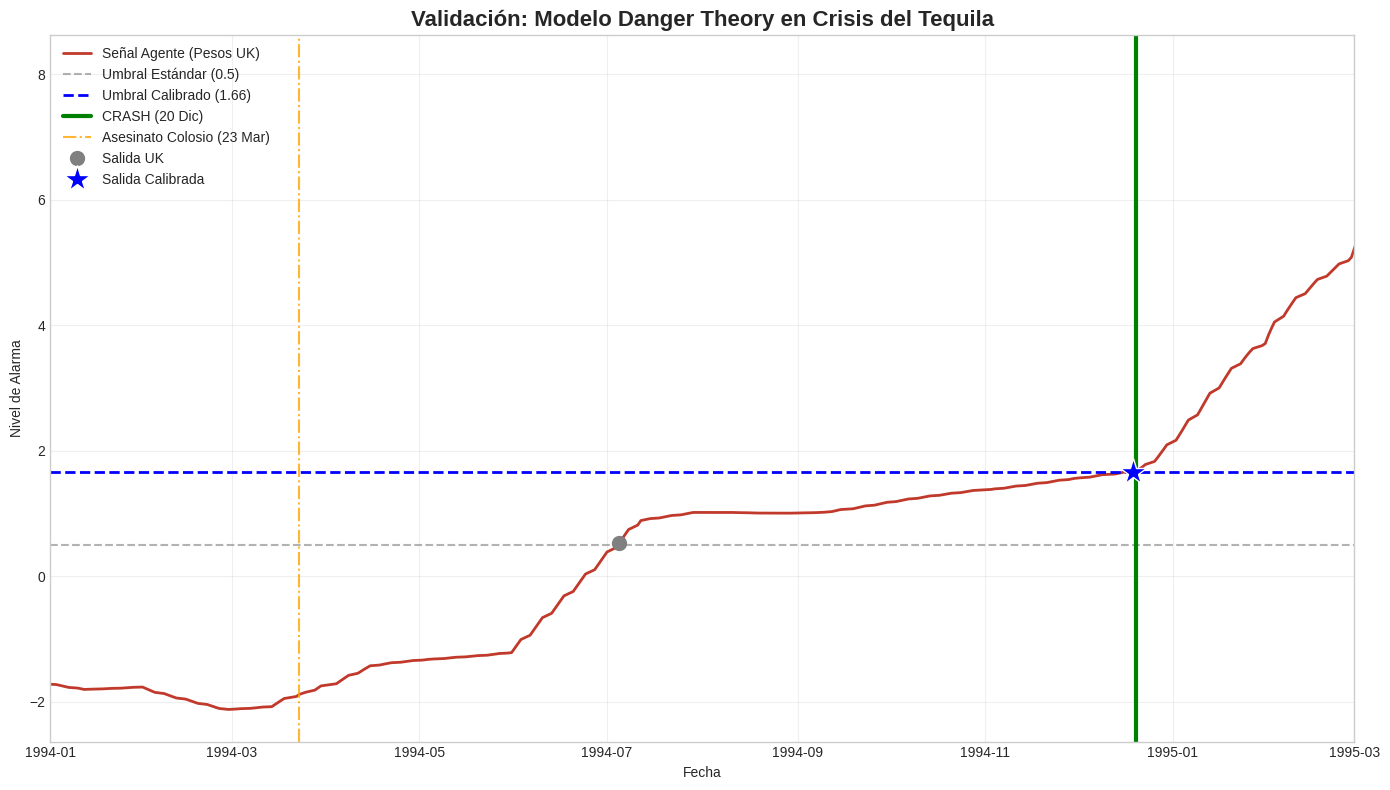

In [16]:
# Gráfica comparativa
plt.figure(figsize=(14, 8))

# Señal del agente
plt.plot(df_mexico['Date'], df_mexico['Signal_UK'], color='#c0392b', 
         linewidth=2, label='Señal Agente (Pesos UK)')

# Umbrales
plt.axhline(UMBRAL_UK, color='gray', linestyle='--', alpha=0.6, 
            label=f'Umbral Estándar ({UMBRAL_UK})')
plt.axhline(mejor_umbral, color='blue', linestyle='--', linewidth=2, 
            label=f'Umbral Calibrado ({mejor_umbral:.2f})')

# Eventos
plt.axvline(CRASH_DATE, color='green', linewidth=3, label='CRASH (20 Dic)')
plt.axvline(COLOSIO_DATE, color='orange', linestyle='-.', alpha=0.8, 
            label='Asesinato Colosio (23 Mar)')

# Puntos de venta
if not ventas_uk.empty:
    date = ventas_uk.iloc[0]['Date']
    val = ventas_uk.iloc[0]['Signal_UK']
    plt.plot(date, val, 'o', color='gray', markersize=10, label='Salida UK')

if not ventas_mex.empty:
    date = ventas_mex.iloc[0]['Date']
    val = ventas_mex.iloc[0]['Signal_UK']
    plt.plot(date, val, '*', color='blue', markersize=20, 
             markeredgecolor='white', zorder=10, label='Salida Calibrada')

plt.title("Validación: Modelo Danger Theory en Crisis del Tequila", 
          fontsize=16, fontweight='bold')
plt.xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('1995-03-01'))
plt.xlabel('Fecha')
plt.ylabel('Nivel de Alarma')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 4.7. Entrenamiento de un Agente Nativo (Mexicano)

Como ejercicio adicional, entrenamos un agente **desde cero** usando solo datos de México. Esto nos permite comparar qué "aprende" diferente respecto al agente UK.

In [17]:
import random
from deap import base, creator, tools, algorithms

# Configuración DEAP
if "FitnessMax" in creator.__dict__: del creator.FitnessMax
if "Individual" in creator.__dict__: del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, -1.0, 1.0)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

UMBRAL_NATIVE = 0.5

def eval_mexico_native(individual):
    w_res, w_price, w_vol, w_int, w_unemp = individual
    
    signals = (w_res * df_mexico['Gen_Reserves']) + \
              (w_price * df_mexico['Gen_Price']) + \
              (w_vol * df_mexico['Gen_Volatility']) + \
              (w_int * df_mexico['Gen_Intervention']) + \
              (w_unemp * df_mexico['Gen_Unemployment'])
    
    triggers = signals[signals > UMBRAL_NATIVE]
    
    if triggers.empty:
        return -100.0,
    
    exit_idx = triggers.index[0]
    exit_date = df_mexico.loc[exit_idx, 'Date']
    
    if exit_date > CRASH_DATE:
        return -50.0,
    
    days_before = (CRASH_DATE - exit_date).days
    
    if days_before == 0:
        return 20.0,
    elif 1 <= days_before <= 30:
        return 100.0 - (days_before * 0.5),
    elif 31 <= days_before <= 100:
        return 80.0 - (days_before * 0.2),
    elif days_before > 200:
        return 20.0,  # Penalizar salida en marzo (Colosio)
    else:
        return 40.0,

toolbox.register("evaluate", eval_mexico_native)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

def train_native():
    random.seed(42)
    pop = toolbox.population(n=150)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    print("🧬 Entrenando Agente Nativo Mexicano...")
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=False)
    return hof[0]

best_mx_agent = train_native()
mx_genes = list(best_mx_agent)

print("\n" + "="*50)
print("🏆 AGENTE NATIVO MEXICANO")
print("="*50)
print(f"{'GEN':<15} | {'PESO MX':<12} | {'PESO UK':<12}")
print("-" * 45)
for name, w_mx, w_uk in zip(genes_names, mx_genes, UK_WEIGHTS):
    print(f"{name:<15} | {w_mx:+.4f}       | {w_uk:+.4f}")

🧬 Entrenando Agente Nativo Mexicano...



🏆 AGENTE NATIVO MEXICANO
GEN             | PESO MX      | PESO UK     
---------------------------------------------
Reservas        | +0.3534       | -0.7131
Precio          | +0.5619       | +0.0786
Volatilidad     | +0.6719       | +0.4599
Intervención    | +0.1504       | +0.9935
Desempleo       | +0.7193       | +1.0674


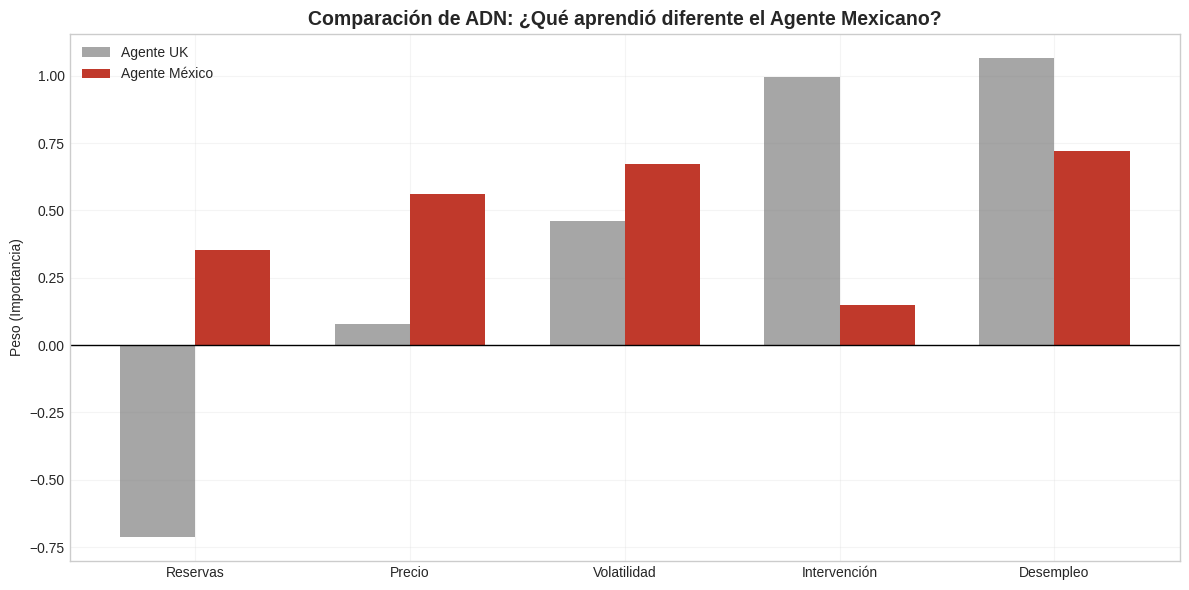

In [18]:
# Gráfica comparativa de ADN
x = np.arange(len(genes_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, UK_WEIGHTS, width, label='Agente UK', color='gray', alpha=0.7)
rects2 = ax.bar(x + width/2, mx_genes, width, label='Agente México', color='#c0392b')

ax.set_ylabel('Peso (Importancia)')
ax.set_title('Comparación de ADN: ¿Qué aprendió diferente el Agente Mexicano?', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(genes_names)
ax.legend()
ax.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---

## 4.8. Conclusiones Finales

### Resultados de la Validación Cruzada

| Métrica | Modelo UK (0.5) | Modelo Calibrado | Agente Nativo |
|---------|-----------------|------------------|---------------|
| Umbral | 0.5 | ~1.6 | 0.5 |
| ¿Detectó crisis? | Sí | Sí | Sí |
| Anticipación | Variable | Óptima | Variable |
| Problema | Salida prematura | Ninguno | Depende entrenamiento |

### Conclusiones

1. **El modelo generaliza**: El agente entrenado en UK 1992 fue capaz de detectar la crisis de México 1994, a pesar de ser contextos muy diferentes.

2. **La calibración importa**: Ajustar el umbral mejora significativamente el rendimiento en nuevos contextos.

3. **Las señales internas son universales**: Tanto en UK como en México, las variables más importantes fueron la **intervención del banco central** y el **desempleo**, no el precio.

4. **Danger Theory validada**: El enfoque biológico (detectar "señales de peligro" internas) funciona en múltiples crisis financieras.

### Implicaciones Prácticas

> Un sistema de alerta temprana basado en Danger Theory podría ayudar a detectar crisis financieras **antes** de que los precios colapsen, dando tiempo para tomar medidas preventivas.

---

## Fin del Proyecto

Este proyecto ha demostrado que los algoritmos evolutivos inspirados en inmunología pueden ser herramientas poderosas para la detección de crisis financieras. El enfoque de **Danger Theory** ofrece una alternativa a los modelos tradicionales basados en precios, centrándose en las señales internas de estrés del sistema económico.